# Thực hành Buổi 06: Data Cleaning & Preprocessing Chuyên sâu

**Khóa đào tạo:** Phân tích Dữ liệu Lớn (Big Data Analysis)

**Công cụ:** Python, Pandas, NumPy, SciPy

**Đầu vào ➔ Đầu ra:** `enterprise_transactions.csv` (bẩn) ➔ dataset sạch hoàn chỉnh (`data/processed/enterprise_transactions_clean.parquet`)

> **Chuỗi bài 06–09** là một pipeline liên tục: Bài 6 làm sạch ➔ Bài 7 tạo đặc trưng ➔ Bài 8 báo cáo KPI ➔ Bài 9 chẩn đoán & phát hiện bất thường. Chạy các cell theo đúng thứ tự từ trên xuống.

## PHẦN 0 — CHUẨN BỊ MÔI TRƯỜNG VÀ DỮ LIỆU

Cell dưới đây sinh ra 2 bộ dữ liệu dùng chung cho **cả chuỗi bài 06–09** (hạt giống cố định `seed=42` nên mọi máy đều ra kết quả giống hệt nhau):

- `data/raw/enterprise_transactions.csv` — ~61.200 dòng giao dịch doanh nghiệp, **cố tình bị làm bẩn** (thiếu MCAR/MAR/MNAR, trùng lặp, sai kiểu dữ liệu, điểm dị biệt, lỗi nhập liệu, giao dịch gian lận).
- `data/raw/customer_churn.csv` — 8.000 hồ sơ khách hàng kèm nhãn rời bỏ (`churn`) — dùng ở Bài 7.

Cột `is_fraud` là **nhãn kiểm chứng** được cấy sẵn — trong thực tế không tồn tại; ta chỉ dùng nó ở cuối Bài 9 để chấm điểm Isolation Forest, tuyệt đối **không** dùng làm đầu vào mô hình.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
pd.options.display.float_format = "{:,.2f}".format

RAW = Path("../data/raw"); RAW.mkdir(parents=True, exist_ok=True)
PROCESSED = Path("../data/processed"); PROCESSED.mkdir(parents=True, exist_ok=True)
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.5 | numpy 2.5.2


In [2]:
# ==== SINH DỮ LIỆU (chạy 1 lần, kết quả cố định nhờ seed=42) ====
rng = np.random.default_rng(42)
N, N_KH = 60_000, 8_000

# --- 1. Nhật ký giao dịch doanh nghiệp ---
DANH_MUC = {"Điện tử": 1_100_000, "Gia dụng": 850_000, "Thực phẩm": 180_000,
            "Thời trang": 750_000, "Sách": 150_000, "Mỹ phẩm": 480_000}
ten_nganh = list(DANH_MUC)
p_nganh = np.array([18, 16, 30, 14, 12, 10], float); p_nganh /= p_nganh.sum()

ts = pd.Timestamp("2025-01-01 07:00:00") + pd.to_timedelta(
    rng.integers(60, 840, N).cumsum(), unit="s")
nganh = rng.choice(ten_nganh, N, p=p_nganh)
unit_price = (np.vectorize(DANH_MUC.get)(nganh)
              * rng.uniform(0.85, 1.15, N) / 1000).astype(int) * 1000
quantity = rng.choice([1, 2, 3, 4, 5], N, p=[.55, .24, .12, .06, .03]).astype(float)
discount = rng.choice([0, .05, .10, .15], N, p=[.60, .20, .12, .08])
amount = unit_price * quantity * (1 - discount)
cost = amount * rng.uniform(0.60, 0.85, N)

p_kh = 1 / np.arange(1, N_KH + 1) ** 0.6; p_kh /= p_kh.sum()
customer_id = np.char.add("C", np.char.zfill(
    (rng.choice(N_KH, N, p=p_kh) + 1).astype(str), 5))

df0 = pd.DataFrame({
    "transaction_id": [f"T{i:07d}" for i in range(1, N + 1)],
    "ts": ts.strftime("%Y-%m-%d %H:%M:%S"),
    "customer_id": customer_id,
    "branch": rng.choice(["Hà Nội", "TP HCM", "Đà Nẵng", "Hải Phòng", "Cần Thơ"],
                         N, p=[.28, .34, .14, .12, .12]),
    "channel": rng.choice(["Online", "Cửa hàng"], N, p=[.45, .55]),
    "category": nganh, "quantity": quantity, "unit_price": unit_price.astype(float),
    "amount": amount, "cost": cost,
    "payment_method": rng.choice(["TIEN_MAT", "THE", "VI_DIEN_TU", "CHUYEN_KHOAN"],
                                 N, p=[.30, .30, .28, .12]),
    "status": rng.choice(["HOAN_TAT", "HOAN_TRA"], N, p=[.965, .035]),
    "is_fraud": 0,
})

# Cấy ~1,2% giao dịch GIAN LẬN: đêm khuya, giá trị lớn bất thường, ví điện tử
i_fraud = rng.choice(N, int(N * 0.012), replace=False)
he_so = rng.uniform(8, 20, i_fraud.size)
df0.loc[i_fraud, "unit_price"] *= he_so
df0.loc[i_fraud, "amount"] = df0.loc[i_fraud, "unit_price"]      # quantity = 1
df0.loc[i_fraud, "quantity"] = 1.0
df0.loc[i_fraud, "cost"] = df0.loc[i_fraud, "amount"] * 0.7
df0.loc[i_fraud, "payment_method"] = "VI_DIEN_TU"
df0.loc[i_fraud, "ts"] = (pd.to_datetime(df0.loc[i_fraud, "ts"]).dt.floor("D")
    + pd.to_timedelta(rng.integers(1, 5, i_fraud.size), unit="h")
    + pd.to_timedelta(rng.integers(0, 3600, i_fraud.size), unit="s")
    ).dt.strftime("%Y-%m-%d %H:%M:%S")
df0.loc[i_fraud, "is_fraud"] = 1

# Cấy 30 LỖI NHẬP LIỆU: amount bị gõ thừa 2 số 0 (x100)
i_err = rng.choice(np.setdiff1d(np.arange(N), i_fraud), 30, replace=False)
df0.loc[i_err, "amount"] *= 100

# KHUYẾT THIẾU — 3 cơ chế:
#   MNAR: amount càng lớn càng hay bị giấu (phụ thuộc chính giá trị bị thiếu)
gia_tri_uoc = df0["quantity"] * df0["unit_price"]
mnar = (gia_tri_uoc > gia_tri_uoc.quantile(0.90)) & (rng.random(len(df0)) < 0.18)
#   MCAR: payment_method mất hoàn toàn ngẫu nhiên ~3%
mcar = rng.random(len(df0)) < 0.03
#   MAR: cost hay thiếu ở kênh Online (25%) hơn Cửa hàng (3%)
mar = np.where(df0["channel"].eq("Online"), rng.random(len(df0)) < 0.25,
               rng.random(len(df0)) < 0.03)

# SAI KIỂU DỮ LIỆU: amount lưu dạng chuỗi có dấu phẩy ngăn cách nghìn
df0["amount"] = df0["amount"].map(lambda x: f"{x:,.0f}")
df0.loc[mnar, "amount"] = np.nan
df0.loc[mcar, "payment_method"] = np.nan
df0.loc[mar, "cost"] = np.nan

# CATEGORY bẩn: 8% dòng bị viết hoa hoặc thừa khoảng trắng
i_bǎn = rng.choice(len(df0), int(len(df0) * 0.08), replace=False)
nua = i_bǎn.size // 2
df0.loc[i_bǎn[:nua], "category"] = df0.loc[i_bǎn[:nua], "category"].str.upper()
df0.loc[i_bǎn[nua:], "category"] = "  " + df0.loc[i_bǎn[nua:], "category"] + " "

# SỐ LƯỢNG VÔ LÝ: 15 dòng quantity âm (lỗi hệ thống)
df0.loc[rng.choice(len(df0), 15, replace=False), "quantity"] *= -1

# TRÙNG LẶP: 800 bản sao y hệt + 400 bản sao chỉ khác transaction_id
dup_exact = df0.sample(800, random_state=1)
dup_near = df0.sample(400, random_state=2).copy()
dup_near["transaction_id"] = [f"TDUP{i:04d}" for i in range(400)]
df_ban = pd.concat([df0, dup_exact, dup_near]).sample(frac=1, random_state=7)
df_ban.to_csv(RAW / "enterprise_transactions.csv", index=False)

# --- 2. Hồ sơ khách hàng + nhãn churn ---
tat_ca_kh = [f"C{i:05d}" for i in range(1, N_KH + 1)]
freq = pd.Series(customer_id).value_counts().reindex(tat_ca_kh).fillna(0).values
tickets = rng.poisson(1.2, N_KH)
tenure = rng.integers(1, 61, N_KH)
z = 0.9 + 0.45 * tickets - 0.22 * freq - 0.030 * tenure
churn = (rng.random(N_KH) < 1 / (1 + np.exp(-z))).astype(int)
pd.DataFrame({
    "customer_id": tat_ca_kh,
    "age": rng.integers(18, 71, N_KH),
    "gender": rng.choice(["Nam", "Nữ"], N_KH),
    "city": rng.choice(["Hà Nội", "TP HCM", "Đà Nẵng", "Hải Phòng", "Cần Thơ"],
                       N_KH, p=[.28, .34, .14, .12, .12]),
    "tenure_months": tenure, "support_tickets": tickets, "churn": churn,
}).to_csv(RAW / "customer_churn.csv", index=False)

print(f"enterprise_transactions.csv : {len(df_ban):,} dòng")
print(f"customer_churn.csv          : {N_KH:,} khách hàng | tỷ lệ churn = {churn.mean():.1%}")
del df0, df_ban, dup_exact, dup_near

enterprise_transactions.csv : 61,200 dòng
customer_churn.csv          : 8,000 khách hàng | tỷ lệ churn = 35.1%


# BÀI 6 — DATA CLEANING & PREPROCESSING CHUYÊN SÂU

**Mục tiêu:** nhận `enterprise_transactions.csv` bẩn ➔ trả ra **dataset sạch hoàn chỉnh**, qua đúng 5 bước chuẩn của mọi dự án dữ liệu:

1. Khám phá & chẩn đoán chất lượng dữ liệu
2. Chuẩn hóa kiểu dữ liệu (dtypes)
3. Xử lý khuyết thiếu theo cơ chế **MCAR / MAR / MNAR**
4. Phát hiện & loại bỏ trùng lặp (duplicate)
5. Phát hiện điểm dị biệt (outlier) bằng **Z-Score** và **IQR**

## 6.1. Nạp dữ liệu và chẩn đoán ban đầu

Nguyên tắc: **chưa sửa gì khi chưa nhìn thấy bệnh**. Ba lệnh khám bệnh đầu tiên luôn là `.info()`, `.head()`, `.describe()`.

In [3]:
tx = pd.read_csv(RAW / "enterprise_transactions.csv")
so_dong_dau_vao = len(tx)
print(f"Kích thước: {tx.shape[0]:,} dòng x {tx.shape[1]} cột")
tx.head()

Kích thước: 61,200 dòng x 13 cột


,transaction_id,ts,customer_id,branch,channel,category,quantity,unit_price,amount,cost,payment_method,status,is_fraud
0,T0009054,2025-02-17 02:08:12,C00947,Hà Nội,Online,Thời trang,3.00,"647,000.00","1,941,000","1,435,615.54",TIEN_MAT,HOAN_TAT,0
1,TDUP0038,2025-05-18 10:38:56,C00002,Cần Thơ,Online,Mỹ phẩm,1.00,"411,000.00","411,000","291,647.95",THE,HOAN_TRA,0
2,T0050630,2025-09-21 10:24:34,C06661,TP HCM,Online,Thực phẩm,5.00,"164,000.00","820,000","551,937.87",THE,HOAN_TAT,0
3,T0019547,2025-04-12 10:45:16,C00492,Cần Thơ,Online,Điện tử,5.00,"1,258,000.00","6,290,000","5,114,514.32",CHUYEN_KHOAN,HOAN_TAT,0
4,T0039940,2025-07-27 17:45:37,C05825,Cần Thơ,Cửa hàng,Thực phẩm,2.00,"163,000.00","326,000","234,988.82",TIEN_MAT,HOAN_TAT,0


In [4]:
tx.info()

<class 'pandas.DataFrame'>
RangeIndex: 61200 entries, 0 to 61199
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  61200 non-null  str    
 1   ts              61200 non-null  str    
 2   customer_id     61200 non-null  str    
 3   branch          61200 non-null  str    
 4   channel         61200 non-null  str    
 5   category        61200 non-null  str    
 6   quantity        61200 non-null  float64
 7   unit_price      61200 non-null  float64
 8   amount          60102 non-null  str    
 9   cost            53289 non-null  float64
 10  payment_method  59330 non-null  str    
 11  status          61200 non-null  str    
 12  is_fraud        61200 non-null  int64  
dtypes: float64(3), int64(1), str(9)
memory usage: 11.0 MB


**Đọc kết quả `.info()` — phát hiện ngay 3 vấn đề:**

1. `ts` và `amount` đang là `object` (chuỗi) — không tính toán được. Đặc biệt `amount` chứa dấu phẩy ngăn cách nghìn (`"1,250,000"`).
2. `amount`, `cost`, `payment_method` có **Non-Null Count nhỏ hơn tổng số dòng** ➔ có khuyết thiếu.
3. Tổng số dòng lớn hơn 60.000 ➔ nghi ngờ trùng lặp.

In [5]:
# category có bao nhiêu "phiên bản" viết khác nhau của cùng một ngành hàng?
print(tx["category"].nunique(), "giá trị khác nhau:")
tx["category"].value_counts()

18 giá trị khác nhau:


category
Thực phẩm        17078
Điện tử          10096
Gia dụng          8949
Thời trang        7932
Sách              6596
Mỹ phẩm           5660
THỰC PHẨM          785
  Thực phẩm        721
  Điện tử          416
ĐIỆN TỬ            411
  Gia dụng         406
GIA DỤNG           357
  Thời trang       350
THỜI TRANG         324
  Sách             303
SÁCH               299
MỸ PHẨM            272
  Mỹ phẩm          245
Name: count, dtype: int64

## 6.2. Chuẩn hóa kiểu dữ liệu (dtypes)

| Cột | Hiện trạng | Đích | Cách làm |
|:---|:---|:---|:---|
| `ts` | chuỗi `"2025-01-01 07:05:12"` | `datetime64` | `pd.to_datetime` |
| `amount` | chuỗi `"1,250,000"` | `float64` | bỏ dấu phẩy rồi `astype(float)` |
| `category` | 18 biến thể viết hoa/thừa khoảng trắng | 6 ngành chuẩn | `.str.strip()` + `.str.capitalize()` |
| `channel`, `payment_method`, `branch`, `status` | `object` lặp lại nhiều | `category` | `astype("category")` — tiết kiệm RAM |

In [6]:
ram_truoc = tx.memory_usage(deep=True).sum() / 1024**2

tx["ts"] = pd.to_datetime(tx["ts"])
tx["amount"] = tx["amount"].str.replace(",", "", regex=False).astype(float)
tx["category"] = tx["category"].str.strip().str.capitalize()
for c in ["branch", "channel", "category", "payment_method", "status"]:
    tx[c] = tx[c].astype("category")

ram_sau = tx.memory_usage(deep=True).sum() / 1024**2
print(f"category còn {tx['category'].nunique()} giá trị: {sorted(tx['category'].cat.categories)}")
print(f"RAM: {ram_truoc:.1f} MB  ->  {ram_sau:.1f} MB (giảm {1 - ram_sau/ram_truoc:.0%})")
tx.dtypes

category còn 6 giá trị: ['Gia dụng', 'Mỹ phẩm', 'Sách', 'Thời trang', 'Thực phẩm', 'Điện tử']
RAM: 11.0 MB  ->  4.8 MB (giảm 56%)


transaction_id               str
ts                datetime64[us]
customer_id                  str
branch                  category
channel                 category
category                category
quantity                 float64
unit_price               float64
amount                   float64
cost                     float64
payment_method          category
status                  category
is_fraud                   int64
dtype: object

## 6.3. Xử lý khuyết thiếu theo cơ chế MCAR / MAR / MNAR

Trước khi điền hay xóa, phải trả lời: **dữ liệu thiếu VÌ SAO?** Ba cơ chế (Rubin, 1976):

| Cơ chế | Tên đầy đủ | Nghĩa | Cách nhận diện | Cách xử lý an toàn |
|:---|:---|:---|:---|:---|
| **MCAR** | Missing Completely At Random | thiếu hoàn toàn ngẫu nhiên, không liên quan gì | tỷ lệ thiếu **đồng đều** trên mọi nhóm | xóa dòng hoặc điền mode/median đều được |
| **MAR** | Missing At Random | thiếu phụ thuộc vào **cột khác quan sát được** | tỷ lệ thiếu **khác hẳn nhau giữa các nhóm** của một cột khác | điền **theo nhóm** (group-wise imputation) |
| **MNAR** | Missing Not At Random | thiếu phụ thuộc vào **chính giá trị bị thiếu** | cần biến đại diện (proxy) để soi | không xóa bừa; tái tạo từ cột khác hoặc mô hình |

Bước 1 — đo mức độ thiếu:

In [7]:
thieu = pd.DataFrame({
    "so_thieu": tx.isna().sum(),
    "ty_le_%": (tx.isna().mean() * 100).round(2),
}).query("so_thieu > 0")
thieu

,so_thieu,ty_le_%
amount,1098,1.79
cost,7911,12.93
payment_method,1870,3.06


In [8]:
# Bằng chứng 1 — payment_method: tỷ lệ thiếu theo kênh và theo ngành hàng
print("Tỷ lệ thiếu payment_method theo channel:")
print(tx.groupby("channel", observed=True)["payment_method"]
        .apply(lambda s: s.isna().mean()).round(4))
print("\nTheo category:")
print(tx.groupby("category", observed=True)["payment_method"]
        .apply(lambda s: s.isna().mean()).round(4))

Tỷ lệ thiếu payment_method theo channel:
channel
Cửa hàng   0.03
Online     0.03
Name: payment_method, dtype: float64

Theo category:
category
Gia dụng     0.03
Mỹ phẩm      0.03
Sách         0.03
Thời trang   0.03
Thực phẩm    0.03
Điện tử      0.03
Name: payment_method, dtype: float64


Tỷ lệ thiếu của `payment_method` **xấp xỉ 3% ở mọi nhóm** ➔ không phụ thuộc biến nào ➔ **MCAR**. Xử lý đơn giản: điền nhãn riêng `"KHONG_RO"` (giữ được dòng, không méo phân phối).

In [9]:
# Bằng chứng 2 — cost: tỷ lệ thiếu theo channel
tx.groupby("channel", observed=True)["cost"].apply(lambda s: s.isna().mean()).round(4)

channel
Cửa hàng   0.03
Online     0.25
Name: cost, dtype: float64

`cost` thiếu **~25% ở kênh Online** nhưng chỉ **~3% ở Cửa hàng** ➔ việc thiếu phụ thuộc vào cột `channel` quan sát được ➔ **MAR**. Nếu điền median toàn cục sẽ méo: đơn Online và Cửa hàng có cơ cấu giá vốn khác nhau. Cách đúng: điền **theo nhóm** — dùng tỷ lệ `cost/amount` trung vị của từng ngành hàng.

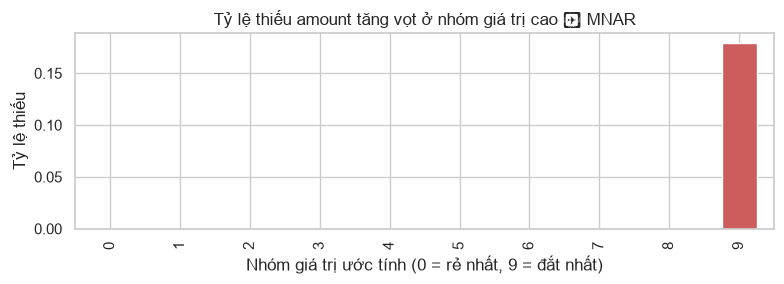

In [10]:
# Bằng chứng 3 — amount: tỷ lệ thiếu theo 10 phân vị của giá trị ước tính
gia_tri_uoc = tx["quantity"].abs() * tx["unit_price"]
bang_mnar = (tx.assign(bin_gia_tri=pd.qcut(gia_tri_uoc, 10, labels=False, duplicates="drop"))
               .groupby("bin_gia_tri")["amount"]
               .apply(lambda s: s.isna().mean()))
ax = bang_mnar.plot(kind="bar", figsize=(8, 3),
                    title="Tỷ lệ thiếu amount tăng vọt ở nhóm giá trị cao ➔ MNAR",
                    color="indianred")
ax.set_xlabel("Nhóm giá trị ước tính (0 = rẻ nhất, 9 = đắt nhất)")
ax.set_ylabel("Tỷ lệ thiếu")
plt.tight_layout(); plt.show()

Giao dịch **càng đắt càng hay bị thiếu `amount`** — việc thiếu phụ thuộc vào chính giá trị bị thiếu ➔ **MNAR**. Nếu xóa các dòng này, ta xóa đúng nhóm giao dịch giá trị cao ➔ mọi KPI doanh thu về sau đều bị **ước lượng thấp**. Cách xử lý: **tái tạo** `amount ≈ quantity × unit_price × (1 − chiết khấu trung vị của ngành)`.

In [11]:
# --- Thực thi 3 phương án xử lý ---
# MCAR: payment_method -> nhãn riêng
tx["payment_method"] = tx["payment_method"].cat.add_categories("KHONG_RO").fillna("KHONG_RO")

# MNAR: tái tạo amount từ quantity x unit_price x hệ số chiết khấu trung vị theo ngành
tx["amount_da_impute"] = tx["amount"].isna()
he_so_ck = (tx["amount"] / (tx["quantity"].abs() * tx["unit_price"])) \
    .groupby(tx["category"], observed=True).median()
tx.loc[tx["amount"].isna(), "amount"] = (
    tx["quantity"].abs() * tx["unit_price"]
    * tx["category"].map(he_so_ck).astype(float))[tx["amount"].isna()]

# MAR: điền cost = amount x tỷ lệ cost/amount trung vị theo ngành
tx["cost_da_impute"] = tx["cost"].isna()
ty_le_von = (tx["cost"] / tx["amount"]).groupby(tx["category"], observed=True).median()
tx.loc[tx["cost"].isna(), "cost"] = (
    tx["amount"] * tx["category"].map(ty_le_von).astype(float))[tx["cost"].isna()]

print("Số ô còn thiếu:", int(tx.isna().sum().sum()))

Số ô còn thiếu: 0


> Hai cột cờ `amount_da_impute`, `cost_da_impute` được giữ lại — người phân tích sau này biết giá trị nào là thật, giá trị nào là ước lượng. Đây là thói quen bắt buộc của một pipeline tử tế.

## 6.4. Phát hiện và loại bỏ trùng lặp

Hai loại trùng lặp khác nhau về bản chất:
- **Trùng tuyệt đối** — mọi cột giống hệt (lỗi ghi log 2 lần) ➔ `duplicated()` mặc định.
- **Trùng nghiệp vụ** — mọi cột giống hệt **trừ khóa** `transaction_id` (cùng một giao dịch bị cấp 2 mã) ➔ `duplicated(subset=...)`.

In [12]:
n0 = len(tx)
print("Trùng tuyệt đối :", tx.duplicated().sum())
cot_nghiep_vu = [c for c in tx.columns if c != "transaction_id"]
print("Trùng nghiệp vụ :", tx.duplicated(subset=cot_nghiep_vu).sum())

tx = tx.drop_duplicates()                                  # bỏ bản sao y hệt
tx = tx.drop_duplicates(subset=cot_nghiep_vu, keep="first")  # bỏ bản sao khác mã
so_trung_loai = n0 - len(tx)
print(f"{n0:,} dòng  ->  {len(tx):,} dòng (loại {so_trung_loai:,} bản trùng)")

Trùng tuyệt đối : 800
Trùng nghiệp vụ : 1200
61,200 dòng  ->  60,000 dòng (loại 1,200 bản trùng)


## 6.5. Điểm dị biệt (Outliers): Z-Score và IQR

Trước tiên loại các dòng **vô lý tuyệt đối** (quantity ≤ 0 — không phải outlier, là dữ liệu sai):

In [13]:
n0 = len(tx)
tx = tx[tx["quantity"] > 0].copy()
so_vo_ly = n0 - len(tx)
print(f"Loại {so_vo_ly} dòng quantity <= 0")

Loại 15 dòng quantity <= 0


Hai thước đo kinh điển trên cột `amount`:

| | **Z-Score** | **IQR (Tukey)** |
|:---|:---|:---|
| Công thức | $z = (x - \bar{x})/s$, dị biệt nếu $\|z\| > 3$ | dị biệt nếu $x < Q_1 - 1.5\,IQR$ hoặc $x > Q_3 + 1.5\,IQR$ |
| Giả định | phân phối gần chuẩn | không cần giả định |
| Điểm yếu | chính outlier kéo $\bar{x}, s$ ➔ che lấp lẫn nhau | trên phân phối lệch phải sẽ gắn cờ rất nhiều điểm |

Dữ liệu giao dịch luôn **lệch phải nặng** — nên xem phân phối trước:

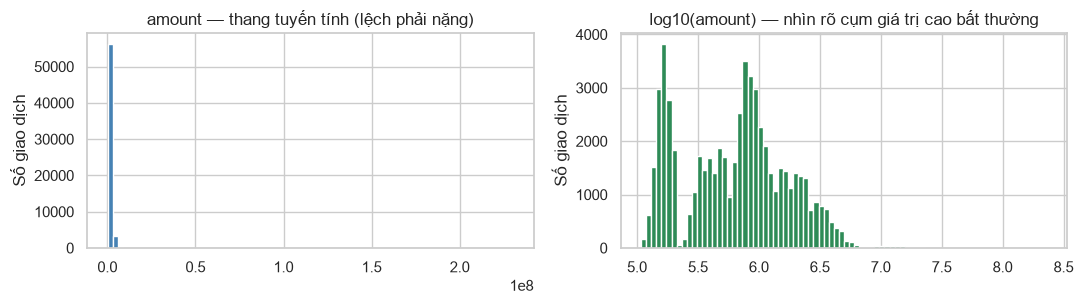

count        59,985.00
mean      1,083,341.05
std       2,442,439.97
min         107,950.00
25%         294,100.00
50%         721,000.00
75%       1,225,000.00
max     230,400,000.00
Name: amount, dtype: float64


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].hist(tx["amount"], bins=80, color="steelblue")
axes[0].set_title("amount — thang tuyến tính (lệch phải nặng)")
axes[1].hist(np.log10(tx["amount"]), bins=80, color="seagreen")
axes[1].set_title("log10(amount) — nhìn rõ cụm giá trị cao bất thường")
for ax in axes: ax.set_ylabel("Số giao dịch")
plt.tight_layout(); plt.show()
print(tx["amount"].describe())

In [15]:
# --- Z-Score (scipy) ---
tx["z_amount"] = stats.zscore(tx["amount"])
co_z = tx["z_amount"].abs() > 3

# --- IQR ---
q1, q3 = tx["amount"].quantile([0.25, 0.75])
iqr = q3 - q1
can_duoi, can_tren = q1 - 1.5 * iqr, q3 + 1.5 * iqr
co_iqr = (tx["amount"] < can_duoi) | (tx["amount"] > can_tren)

print(f"Z-Score |z|>3 gắn cờ : {co_z.sum():>6,} dòng ({co_z.mean():.2%})")
print(f"IQR 1.5xIQR gắn cờ   : {co_iqr.sum():>6,} dòng ({co_iqr.mean():.2%})")
print(f"Ngưỡng IQR trên      : {can_tren:,.0f} đ")
print(f"Cả hai cùng gắn cờ   : {(co_z & co_iqr).sum():,} dòng")

Z-Score |z|>3 gắn cờ :    333 dòng (0.56%)
IQR 1.5xIQR gắn cờ   :  4,719 dòng (7.87%)
Ngưỡng IQR trên      : 2,621,350 đ
Cả hai cùng gắn cờ   : 333 dòng


Đúng như lý thuyết: trên phân phối lệch phải, **IQR gắt hơn Z-Score rất nhiều**. Nhưng câu hỏi quan trọng hơn là: *outlier này là RÁC hay là TÍN HIỆU?*

- **Rác (lỗi nhập liệu):** `amount` gấp ~100 lần `quantity × unit_price` — gõ thừa hai số 0. Kiểm chứng được bằng chính dữ liệu ➔ **sửa lại**.
- **Tín hiệu (giao dịch thật nhưng bất thường):** giá trị lớn nhưng nhất quán với `unit_price` ➔ **giữ lại và gắn cờ** — đây chính là "nguyên liệu" cho bài toán phát hiện gian lận ở Bài 9. Xóa chúng bây giờ là tự tay vứt bỏ tín hiệu.

In [16]:
# Sửa lỗi nhập liệu: amount lệch ~x100 so với quantity x unit_price
ty_le = tx["amount"] / (tx["quantity"] * tx["unit_price"])
loi_nhap = ty_le > 10
so_loi_nhap = int(loi_nhap.sum())
print(f"Lỗi nhập liệu x100 phát hiện: {so_loi_nhap} dòng — sửa bằng cách chia 100")
tx.loc[loi_nhap, "amount"] /= 100
tx.loc[loi_nhap, "cost"] = tx.loc[loi_nhap, "amount"] * ty_le_von.reindex(
    tx.loc[loi_nhap, "category"]).values

# Gắn cờ (không xóa) các outlier còn lại theo IQR — tính lại sau khi đã sửa lỗi
q1, q3 = tx["amount"].quantile([0.25, 0.75]); iqr = q3 - q1
tx["la_outlier_iqr"] = (tx["amount"] < q1 - 1.5 * iqr) | (tx["amount"] > q3 + 1.5 * iqr)
tx = tx.drop(columns="z_amount")
print(f"Outlier IQR còn lại (giữ + gắn cờ): {tx['la_outlier_iqr'].sum():,} dòng")

Lỗi nhập liệu x100 phát hiện: 30 dòng — sửa bằng cách chia 100
Outlier IQR còn lại (giữ + gắn cờ): 4,696 dòng


## 6.6. Lưu dataset sạch và tổng kết pipeline

In [17]:
tx = tx.sort_values("ts").reset_index(drop=True)
tx.to_parquet(PROCESSED / "enterprise_transactions_clean.parquet", index=False)

tong_ket = pd.DataFrame([
    ["Dòng đầu vào (CSV bẩn)",            f"{so_dong_dau_vao:,}"],
    ["Loại trùng tuyệt đối + nghiệp vụ",  f"-{so_trung_loai:,}"],
    ["Loại quantity <= 0",                f"-{so_vo_ly}"],
    ["Sửa lỗi nhập liệu x100",            f"{so_loi_nhap} dòng sửa tại chỗ"],
    ["Điền MCAR/MAR/MNAR",                "0 ô trống còn lại"],
    ["Dòng đầu ra (parquet sạch)",        f"{len(tx):,}"],
], columns=["Bước", "Kết quả"])
print(tong_ket.to_string(index=False))
print("\nĐã lưu:", PROCESSED / "enterprise_transactions_clean.parquet")

                            Bước             Kết quả
          Dòng đầu vào (CSV bẩn)              61,200
Loại trùng tuyệt đối + nghiệp vụ              -1,200
              Loại quantity <= 0                 -15
          Sửa lỗi nhập liệu x100 30 dòng sửa tại chỗ
              Điền MCAR/MAR/MNAR   0 ô trống còn lại
      Dòng đầu ra (parquet sạch)              59,985

Đã lưu: ..\data\processed\enterprise_transactions_clean.parquet


---
# BÀI TẬP VỀ NHÀ

Làm trực tiếp vào các cell trống bên dưới. Nộp notebook đã chạy đầy đủ output.

#### Bài tập 1 (Missing): Cột `payment_method` được kết luận là MCAR. Hãy tự kiểm chứng lại bằng cách tính tỷ lệ thiếu theo `branch` và theo `status` (trên dữ liệu đọc lại từ CSV gốc). Kết quả có ủng hộ kết luận MCAR không? Viết 2–3 câu nhận xét.

In [18]:
# --- BÀI TẬP 1 ---


#### Bài tập 2 (Outlier): Áp dụng Z-Score và IQR cho cột `quantity` thay vì `amount`. Hai phương pháp gắn cờ bao nhiêu dòng? Theo em `quantity = 5` có đáng bị coi là outlier không, vì sao?

In [19]:
# --- BÀI TẬP 2 ---
